In [4]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from utils import *
# torch.set_printoptions(linewidth=100, precision=4, sci_mode=False, threshold=2000)

# TODO: If I substituted every dictionary usage with named_tuple, would that be much faster and worth the effort?

seed: int = 1
torch_deterministic: bool = True
totalTimesteps: int = 500
graph = True
bufferSize: int = int(1e5)
gamma: float = 0.9
tau: float = 0.05
batch_size: int = 64
learning_starts: int = 200
actorLR: float = 1e-3
criticLR: float = 1e-3
update_frequency: int = 1
target_network_frequency: int = 1
targetEntropy_scale: float = 0.9


def layer_init(layer, bias_const=0.0):
    nn.init.kaiming_normal_(layer.weight)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = torch_deterministic
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# env = UnityInterface("Builds\\Windows\\Ball3D\\UnityEnvironment", seed=seed)      # 1D obs only, continuous action of size 2. Rewards: 0.1 for every step, -1 for fail, 100 is the max episodic return
# env = UnityInterface("Builds\\Windows\\Crawler\\UnityEnvironment", seed=seed)     # 1D obs only, continuous action of size 8
# env = UnityInterface("Builds\\Windows\\PushBlock\\UnityEnvironment", seed=seed)   # 1D obs only, discrete action of size (7). Rewards: 5 for win, -0.001 for every step
# env = UnityInterface("Builds\\Windows\\WallJump\\UnityEnvironment", seed=seed)    # 1D obs only, discrete action of size (3, 3, 3, 2)

# env = UnityInterface("Builds/Linux/Ball3D/Ball3D", seed=seed)                     # 1D obs only, continuous action of size 2. Rewards: 0.1 for every step, -1 for fail, 100 is the max episodic return
# env = UnityInterface("Builds/Linux/PushBlock/PushBlock", seed=seed)               # 1D obs only, discrete action of size (7). Rewards: 5 for win, -0.001 for every step
# env = UnityInterface("Builds/Linux/WallJump/WallJump", seed=seed)                 # 1D obs only, discrete action of size (3, 3, 3, 2)

env = UnityInterface(None, seed=seed) 

print(f"{env.getSpecs()}")
behaviorNames = env.getBehaviorNames()

totalAgentsCounts = 10000
for behavior in behaviorNames:
    totalAgentsCounts += (env.getSpecs(behavior)["AgentsCount"])

actor, actorOptimizer, memory, observationBuffer, actionsBuffer, = {}, {}, {}, {}, {}
QFunction1, QFunction2, QFunction1Target, QFunction2Target, criticOptimizer = {}, {}, {}, {}, {}
targetEntropy, logAlpha, alpha, alphaOptimizer = {}, {}, {}, {}
for behavior in behaviorNames:
    envSpecs = env.getSpecs(behavior)
    actor[behavior] = SAC(envSpecs).to(device)
    actorOptimizer[behavior] = optim.Adam(list(actor[behavior].parameters()), lr=actorLR)
    QFunction1[behavior] = QNetwork(envSpecs).to(device)
    QFunction2[behavior] = QNetwork(envSpecs).to(device)
    QFunction1Target[behavior] = QNetwork(envSpecs).to(device)
    QFunction2Target[behavior] = QNetwork(envSpecs).to(device)
    QFunction1Target[behavior].load_state_dict(QFunction1[behavior].state_dict())
    QFunction2Target[behavior].load_state_dict(QFunction2[behavior].state_dict())
    criticOptimizer[behavior] = optim.Adam(list(QFunction1[behavior].parameters()) + list(QFunction2[behavior].parameters()), lr=criticLR)
    
    memory[behavior] = Memory(bufferSize)
    assert actor[behavior].usingContinuousActions or actor[behavior].usingDiscreteActions, "Agent not using continuous nor discrete actions, VERY BAD"

    # Alpha tuning init
    targetEntropy[behavior] = torch.tensor((0), dtype=torch.float, device=device)
    divider = 0
    if actor[behavior].usingDiscreteActions:
        targetEntropy[behavior] -= targetEntropy_scale * torch.log(1 / torch.tensor(env.getSpecs(behavior)["DiscreteActions"]).prod().to(device))
        divider += 1
    if actor[behavior].usingContinuousActions:
        targetEntropy[behavior] -= torch.tensor(env.getSpecs(behavior)["ContinuousActions"]).to(device)
        divider += 1
    targetEntropy[behavior] /= divider

    logAlpha[behavior] = torch.zeros(1, requires_grad=True, device=device)
    alpha[behavior] = logAlpha[behavior].exp().item()
    alphaOptimizer[behavior] = optim.Adam([logAlpha[behavior]], lr=criticLR)

# FIXME: Add actions buffer continuous and discrete and test 3DBall
observationBuffer = [None] * totalAgentsCounts
for i in range(totalAgentsCounts):
    actionsBuffer[i] = {'continuous': None, 'discrete': None}
rewards = np.zeros(totalAgentsCounts)

finalRewards, criticLosses, actorLosses, alphaLosses, alphas, QEvaluations, logProbs = [], [], [], [], [], [], []
for globalStep in range(1, totalTimesteps+1):
    for behavior in behaviorNames:
        decisionSteps, terminalSteps = env.getSteps(behavior)
        observationsThatNeedAction = []
        for agent in decisionSteps:
            observation = decisionSteps[agent].obs
            observationsThatNeedAction.append(observation)
            reward = decisionSteps[agent].reward * 100
            lastObservation = observationBuffer[agent]
            lastActionContinuous = actionsBuffer[agent]['continuous']
            lastActionDiscrete = actionsBuffer[agent]['discrete']
            if lastObservation != None and (lastActionContinuous != None or lastActionDiscrete != None):
                memory[behavior].push(lastObservation, lastActionContinuous, lastActionDiscrete, reward, False, observation)
            observationBuffer[agent] = observation
            rewards[agent] += reward
            
        for agent in terminalSteps:
            observation = terminalSteps[agent].obs
            reward = terminalSteps[agent].reward * 100
            lastObservation = observationBuffer[agent]
            lastActionContinuous = actionsBuffer[agent]['continuous']
            lastActionDiscrete = actionsBuffer[agent]['discrete']
            # Technically could skip the action None check. If lastObs exist, action does too
            if lastObservation != None and (lastActionContinuous != None or lastActionDiscrete != None):
                memory[behavior].push(lastObservation, lastActionContinuous, lastActionDiscrete, reward, True, observation)
                observationBuffer[agent] = None
                actionsBuffer[agent]['continuous'] = None
                actionsBuffer[agent]['discrete'] = None
                # Save rewards only if we made an action before, otherwise the initial state was terminated state
                rewards[agent] += reward
                if rewards[agent] > 4:
                    print(f"Final reward: {rewards[agent]:>.2f}")
            finalRewards.append(rewards[agent])
            rewards[agent] = 0

        
        behaviorActionsForThisStep = {}
        specs = env.getSpecs(behavior)
        nrOfContinuousActions = specs["ContinuousActions"] # TODO: Substitute it with actors[behavior].usingContinuousActions
        nrOfDiscreteActions = len(specs["DiscreteActions"])
        behaviorActionsForThisStep["continuous"] = torch.zeros((len(decisionSteps), nrOfContinuousActions), requires_grad=False, dtype=torch.float32, device=device)
        behaviorActionsForThisStep["discrete"] = torch.zeros((len(decisionSteps), nrOfDiscreteActions), requires_grad=False, dtype=torch.long, device=device)
        # print(f"Allocated discrete action buffer of shape {behaviorActionsForThisStep['discrete'].shape}")

        # Batched pass to get actions  
        if len(observationsThatNeedAction) > 0:
            if actor[behavior].usingContinuousActions:
                behaviorActionsForThisStep["continuous"], _ = actor[behavior].getContinuousAction(observationsThatNeedAction, withLogProbs=False)
            if actor[behavior].usingDiscreteActions:
                behaviorActionsForThisStep["discrete"], _, _ = actor[behavior].getDiscreteAction((observationsThatNeedAction), withLogProbs=False)

        # Transcribe the actions to buffer
            for j, agent in enumerate(decisionSteps):
                if nrOfContinuousActions > 0:
                    actionsBuffer[agent]['continuous'] = behaviorActionsForThisStep['continuous'][j]
                if nrOfDiscreteActions > 0:
                    actionsBuffer[agent]['discrete'] = behaviorActionsForThisStep['discrete'][j]

        # print(f"Setting Continuous actions: {behaviorActionsForThisStep}, Discrete actions: {behaviorActionsForThisStep}")
        # print(f"Discrete action buffer shape before detachcpunumpy: {behaviorActionsForThisStep['discrete'].shape}")
        # print(f"Discrete action buffer shape after detachcpunumpy: {behaviorActionsForThisStep['discrete'].detach().cpu().numpy().shape}")
        env.setActions(behavior, behaviorActionsForThisStep['continuous'].detach().cpu().numpy(), behaviorActionsForThisStep['discrete'].detach().cpu().numpy())
    env.step()
    
    # ALGO LOGIC: training.
    if globalStep > learning_starts:
        if globalStep % update_frequency == 0:
            data = memory[behavior].sample(batch_size)
            observationsBatch       =               data.observations
            actionsContinuousBatch  =               torch.stack(data.actionsContinuous) if actor[behavior].usingContinuousActions else None
            actionsDiscreteBatch    =               torch.stack(data.actionsDiscrete) if actor[behavior].usingDiscreteActions else None
            rewardsBatch            =               torch.from_numpy(np.stack(data.rewards, dtype=np.float32)).to(device)
            isThereNextStepBatch    =               torch.logical_not(torch.tensor(np.stack(data.dones), device=device, dtype=torch.float32))
            nextObservationsBatch   =               data.nextObservations
            
            # #################### CRITIC UPDATE
            with torch.no_grad():
                nextStateActionsContinuous, nextStateActionsDiscrete, nextStateLogProbsContinuous, nextStateLogProbsDiscrete, nextStateProbsDiscrete, divider = None, None, 0, 0, 1, 0
                if actor[behavior].usingContinuousActions:
                    nextStateActionsContinuous, nextStateLogProbsContinuous = actor[behavior].getContinuousAction(nextObservationsBatch)
                    divider += 1
                if actor[behavior].usingDiscreteActions:
                    nextStateActionsDiscrete, nextStateLogProbsDiscrete, nextStateProbsDiscrete = actor[behavior].getDiscreteAction(nextObservationsBatch)
                    divider += 1

                QFunction1NextTarget = QFunction1Target[behavior](nextObservationsBatch, nextStateActionsContinuous, nextStateActionsDiscrete)
                QFunction2NextTarget = QFunction2Target[behavior](nextObservationsBatch, nextStateActionsContinuous, nextStateActionsDiscrete)
                minQNextTarget = nextStateProbsDiscrete * (torch.min(QFunction1NextTarget, QFunction2NextTarget) - (alpha[behavior] * (nextStateLogProbsContinuous + nextStateLogProbsDiscrete) / divider))
                if minQNextTarget.ndim > 1:
                    minQNextTarget = torch.sum(minQNextTarget, axis=tuple(range(1, minQNextTarget.ndim)))
                nextQValue = rewardsBatch + isThereNextStepBatch * gamma * minQNextTarget
                
            QFunction1ActionValues = QFunction1[behavior](observationsBatch, actionsContinuousBatch.detach() if actor[behavior].usingContinuousActions else None, actionsDiscreteBatch.detach() if actor[behavior].usingDiscreteActions else None)
            QFunction2ActionValues = QFunction2[behavior](observationsBatch, actionsContinuousBatch.detach() if actor[behavior].usingContinuousActions else None, actionsDiscreteBatch.detach() if actor[behavior].usingDiscreteActions else None)
            if actor[behavior].usingDiscreteActions:
                QFunction1ActionValues = gatherEvaluationOfTakenActions(QFunction1ActionValues, actionsDiscreteBatch)
                QFunction2ActionValues = gatherEvaluationOfTakenActions(QFunction2ActionValues, actionsDiscreteBatch)
            QFunction1Loss = F.mse_loss(QFunction1ActionValues, nextQValue)
            QFunction2Loss = F.mse_loss(QFunction2ActionValues, nextQValue)
            criticLoss = QFunction1Loss + QFunction2Loss
            criticOptimizer[behavior].zero_grad()
            criticLoss.backward()
            criticOptimizer[behavior].step()



            # #################### ACTOR UPDATE
            stateActionsContinuous, stateActionsDiscrete, stateLogProbsContinuous, stateLogProbsDiscrete, stateProbsDiscrete, divider = None, None, torch.tensor(0, device=device), torch.tensor(0, device=device), torch.tensor(1, device=device), torch.tensor(0, device=device)
            if actor[behavior].usingContinuousActions:
                stateActionsContinuous, stateLogProbsContinuous = actor[behavior].getContinuousAction(observationsBatch)
                divider += 1
            if actor[behavior].usingDiscreteActions:
                stateActionsDiscrete, stateLogProbsDiscrete, stateProbsDiscrete = actor[behavior].getDiscreteAction(observationsBatch)
                divider += 1

            QFunction1Evaluation = QFunction1[behavior](observationsBatch, stateActionsContinuous, stateActionsDiscrete)
            QFunction2Evaluation = QFunction1[behavior](observationsBatch, stateActionsContinuous, stateActionsDiscrete)
            minQEvaluation = torch.min(QFunction1Evaluation, QFunction2Evaluation)
            actorLoss = (stateProbsDiscrete * ((alpha[behavior] * (stateLogProbsContinuous + stateLogProbsDiscrete) / divider) - minQEvaluation)).mean()
            actorOptimizer[behavior].zero_grad()
            actorLoss.backward()
            actorOptimizer[behavior].step()



            # #################### ALPHA UPDATE
            logProbabilitiesC, logProbabilitiesD, probsD, divider = torch.tensor(0, device=device), torch.tensor(0, device=device), torch.tensor(1, device=device), 0
            if actor[behavior].usingContinuousActions:
                _, logProbabilitiesC = actor[behavior].getContinuousAction(observationsBatch)
                divider += 1
            if actor[behavior].usingDiscreteActions:
                _, logProbabilitiesD, probsD = actor[behavior].getDiscreteAction(observationsBatch)
                divider += 1
            alphaLoss = (probsD.detach()*(-logAlpha[behavior].exp()*((logProbabilitiesC.to(device) + logProbabilitiesD.to(device)) / divider + targetEntropy[behavior]).detach())).mean()
            alphaOptimizer[behavior].zero_grad()
            alphaLoss.backward()
            alphaOptimizer[behavior].step()
            alpha[behavior] = logAlpha[behavior].exp().item()



            # update the target networks
            if globalStep % target_network_frequency == 0:
                for param, targetParam in zip(QFunction1[behavior].parameters(), QFunction1Target[behavior].parameters()):
                    targetParam.data.copy_(tau * param.data + (1 - tau) * targetParam.data)
                for param, targetParam in zip(QFunction2[behavior].parameters(), QFunction2Target[behavior].parameters()):
                    targetParam.data.copy_(tau * param.data + (1 - tau) * targetParam.data)

            if globalStep % 200 == 0:
                print(f"Step {globalStep}, Actor loss: {actorLoss:>8.4f}, QF loss: {criticLoss:>8.4f}")


            if globalStep % 1 == 0:
                criticLosses.append(criticLoss)
                actorLosses.append(actorLoss)
                alphaLosses.append(alphaLoss)
                alphas.append(alpha[behavior])
                QEvaluations.append(minQEvaluation.mean())
                logProbs.append(((stateLogProbsContinuous + stateLogProbsDiscrete) / divider).mean())
env.close()

{'Basic?team=0': {'AgentsCount': 1, 'Observations': [(20,)], 'ContinuousActions': 0, 'DiscreteActions': (3,)}}
Final reward: 90.00
Final reward: 39.00
Final reward: 7.00
Final reward: 4.00
Final reward: 43.00
Final reward: 62.00
Final reward: 7.00
Final reward: 7.00
Final reward: 6.00
Final reward: 7.00
Final reward: 7.00
Final reward: 4.00
Final reward: 7.00
Final reward: 6.00
Final reward: 7.00
Final reward: 5.00
Final reward: 7.00
Final reward: 91.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Final reward: 93.00
Fi

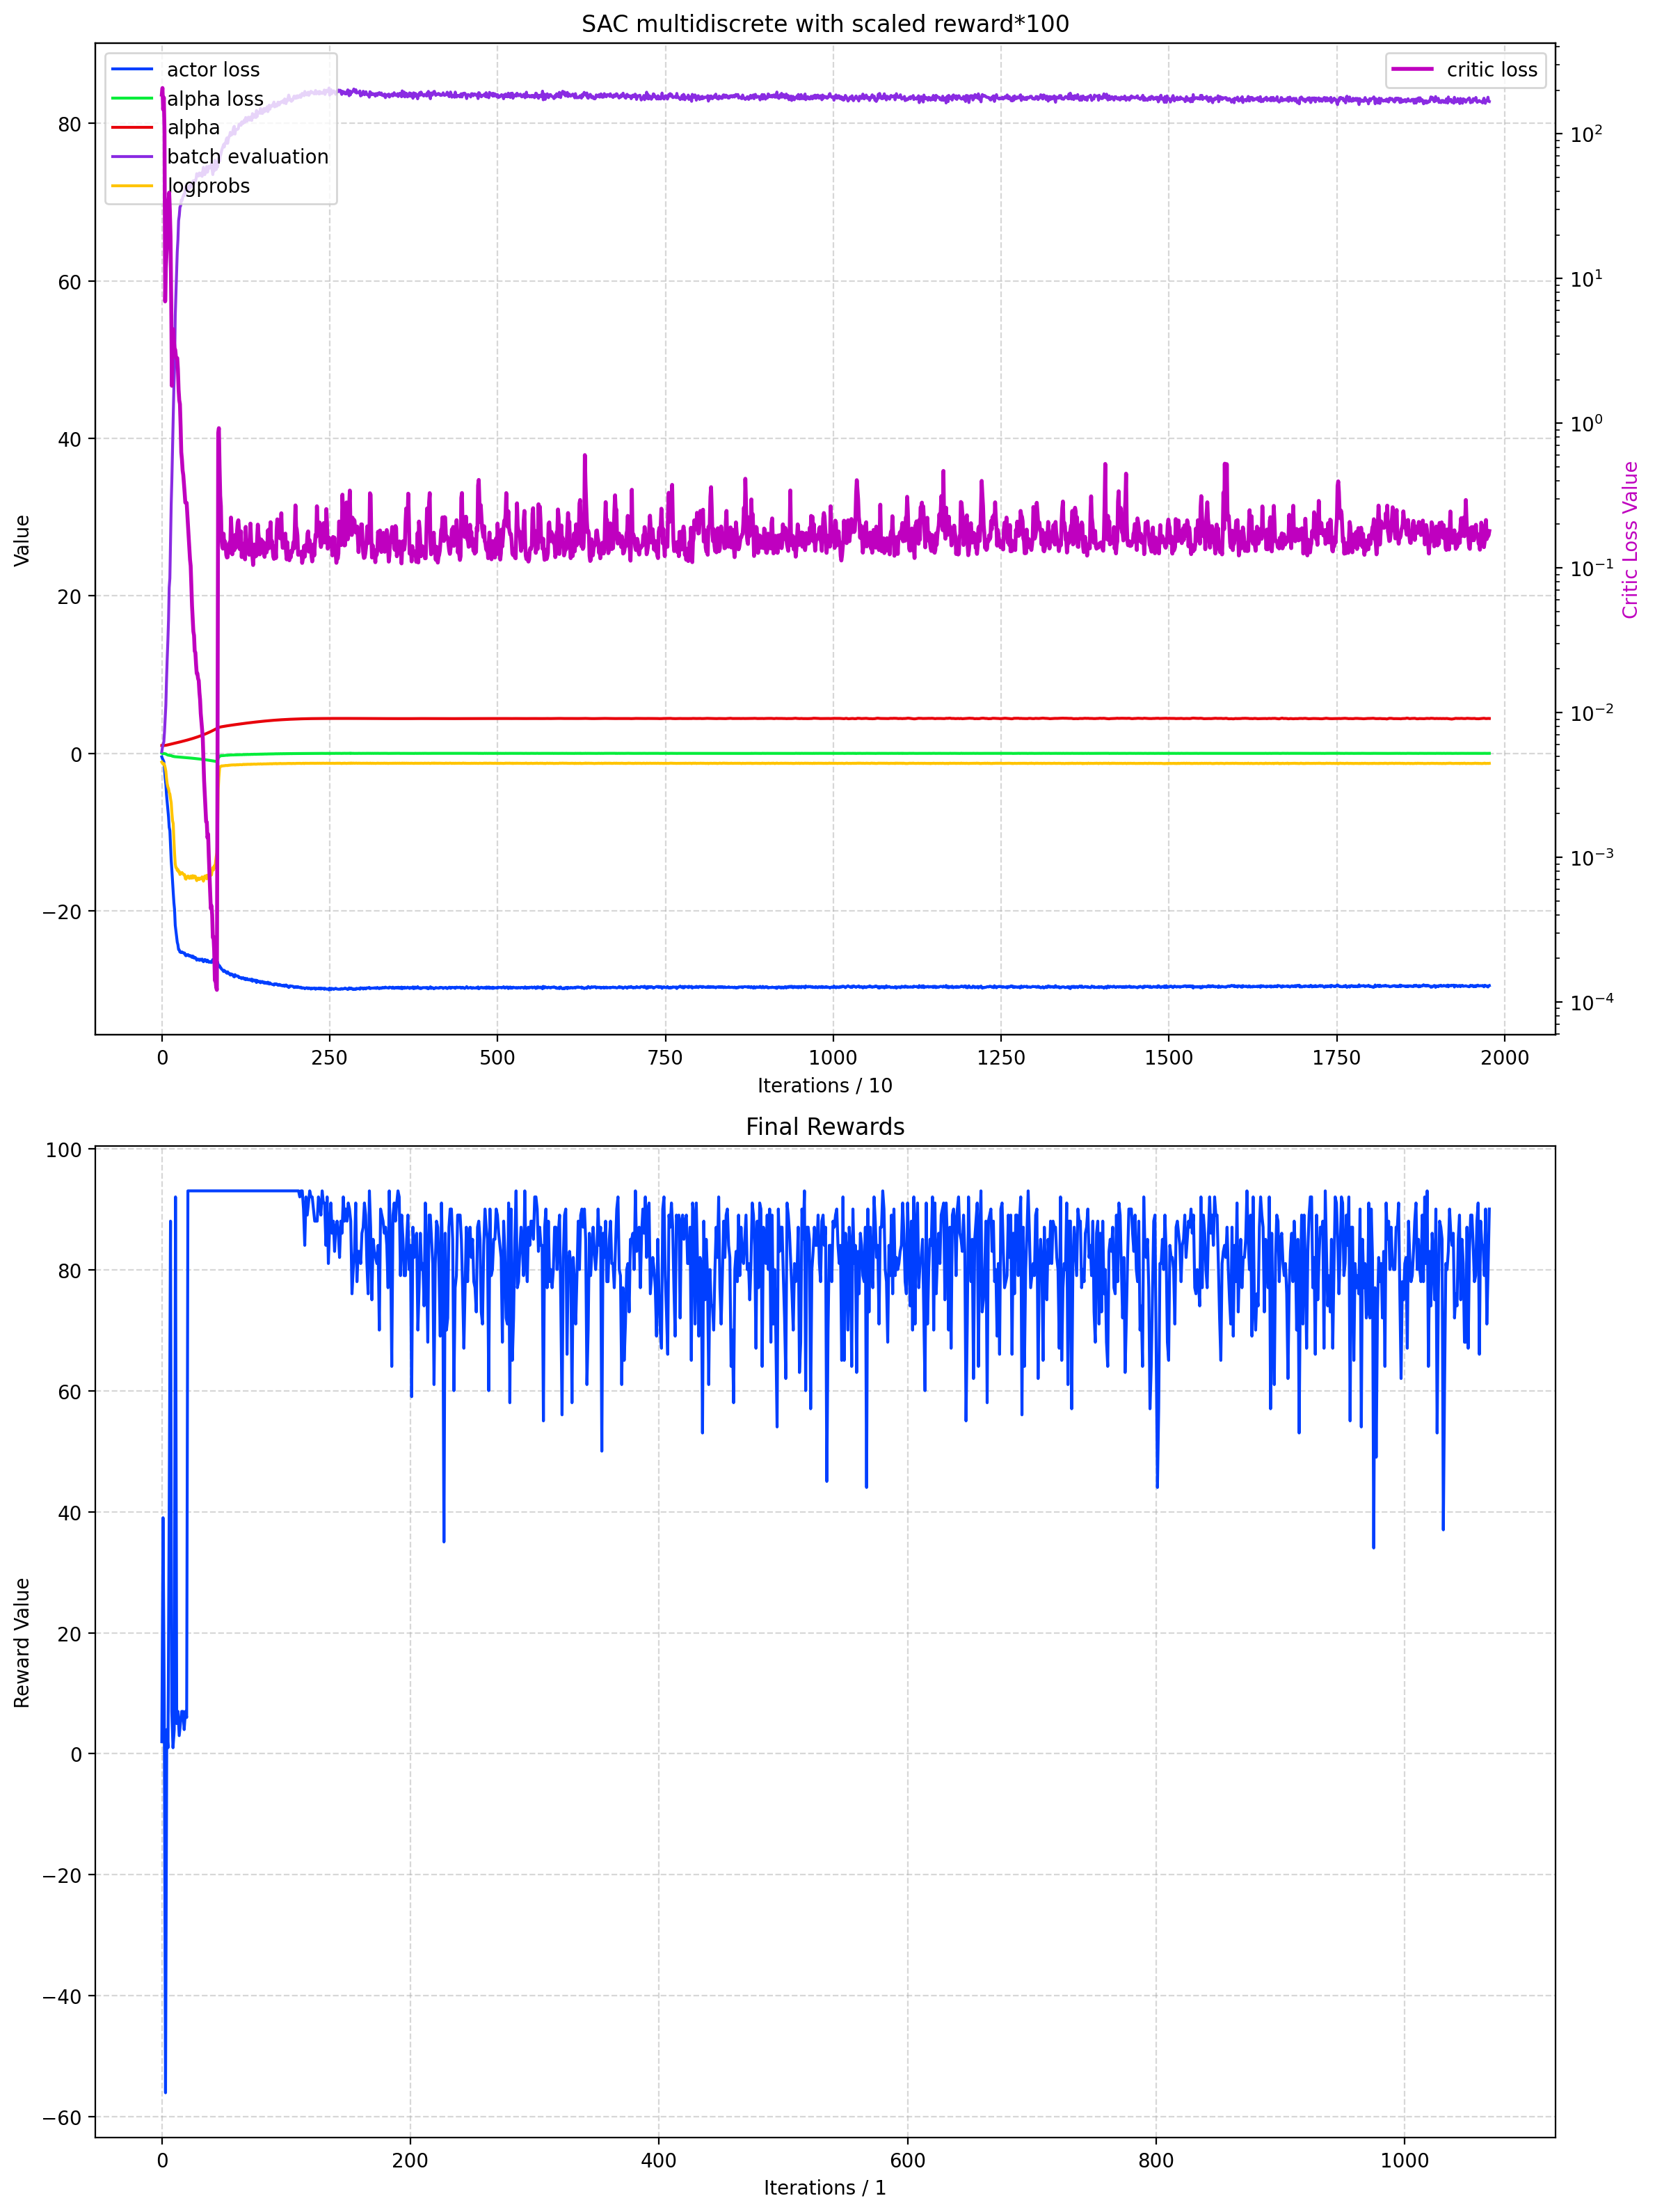

In [2]:
if graph:
    averagingNr = 1
    beginning = 1
    dif = ((len(criticLosses) - beginning) % averagingNr) + averagingNr

    # Style
    plt.style.use('seaborn-v0_8-bright')

    fig, (ax1, ax2) = plt.subplots(2, 1)

    ax1.plot(torch.tensor(actorLosses[beginning:-dif]).view(-1, averagingNr).mean(-1), label="actor loss")
    ax1.plot(torch.tensor(alphaLosses[beginning:-dif]).view(-1, averagingNr).mean(-1), label="alpha loss")
    ax1.plot(torch.tensor(alphas[beginning:-dif]).view(-1, averagingNr).mean(-1), label="alpha")
    ax1.plot(torch.tensor(QEvaluations[beginning:-dif]).view(-1, averagingNr).mean(-1), label="batch evaluation")
    ax1.plot(torch.tensor(logProbs[beginning:-dif]).view(-1, averagingNr).mean(-1), label="logprobs")
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, fancybox=True, shadow=True)
    ax1b = ax1.twinx()
    ax1b.plot(torch.tensor(criticLosses[beginning:-dif]).view(-1, averagingNr).mean(-1), 'm-', label="critic loss")
    ax1b.set_ylabel("Critic Loss Value", color='m')
    ax1b.tick_params(axis='y')
    plt.gca().set_yscale('log')

    ax1.set_title("SAC multidiscrete 500 steps basic env")
    ax1.set_xlabel(f"Iterations / {averagingNr}")
    ax1.set_ylabel("Value")
    ax1.grid(True, linestyle='--', alpha=0.5)


    averagingNrR = 1
    dif_rewards = ((len(finalRewards) - beginning) % averagingNrR) + averagingNrR
    ax2.plot(torch.tensor(finalRewards[beginning:-dif_rewards]).view(-1, averagingNrR).mean(-1))
    ax2.set_title("Final Rewards")
    ax2.set_xlabel(f"Episode")
    ax2.set_ylabel("Reward")
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.legend()
    plt.tight_layout()
    # plt.subplots_adjust(left=0.076, right=0.922, bottom=0.11, top=0.95, hspace=0.487)
    plt.show()

In [3]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from utils import *
# torch.set_printoptions(linewidth=100, precision=4, sci_mode=False, threshold=2000)

# TODO: If I substituted every dictionary usage with named_tuple, would that be much faster and worth the effort?

seed: int = 1
torch_deterministic: bool = True
totalTimesteps: int = 10000
graph = True
bufferSize: int = int(1e5)
gamma: float = 0.99
tau: float = 1
batch_size: int = 128
learning_starts: int = 200
actorLR: float = 1e-3
criticLR: float = 1e-3
update_frequency: int = 1
target_network_frequency: int = 1000
targetEntropy_scale: float = 0.9


def layer_init(layer, bias_const=0.0):
    nn.init.kaiming_normal_(layer.weight)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = torch_deterministic
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# env = UnityInterface("Builds\\Windows\\Ball3D\\UnityEnvironment", seed=seed)      # 1D obs only, continuous action of size 2. Rewards: 0.1 for every step, -1 for fail, 100 is the max episodic return
# env = UnityInterface("Builds\\Windows\\Crawler\\UnityEnvironment", seed=seed)     # 1D obs only, continuous action of size 8
# env = UnityInterface("Builds\\Windows\\PushBlock\\UnityEnvironment", seed=seed)   # 1D obs only, discrete action of size (7). Rewards: 5 for win, -0.001 for every step
# env = UnityInterface("Builds\\Windows\\WallJump\\UnityEnvironment", seed=seed)    # 1D obs only, discrete action of size (3, 3, 3, 2)

# env = UnityInterface("Builds/Linux/Ball3D/Ball3D", seed=seed)                     # 1D obs only, continuous action of size 2. Rewards: 0.1 for every step, -1 for fail, 100 is the max episodic return
# env = UnityInterface("Builds/Linux/PushBlock/PushBlock", seed=seed)               # 1D obs only, discrete action of size (7). Rewards: 5 for win, -0.001 for every step
# env = UnityInterface("Builds/Linux/WallJump/WallJump", seed=seed)                 # 1D obs only, discrete action of size (3, 3, 3, 2)

env = UnityInterface(None, seed=seed) 
for globalStep in range(1, totalTimesteps+1):
    for behavior in behaviorNames:
        decisionSteps, terminalSteps = env.getSteps(behavior)
        observationsThatNeedAction = []
        for agent in decisionSteps:
            observation = decisionSteps[agent].obs
            observationsThatNeedAction.append(observation)
            reward = decisionSteps[agent].reward * 100
            lastObservation = observationBuffer[agent]
            lastActionContinuous = actionsBuffer[agent]['continuous']
            lastActionDiscrete = actionsBuffer[agent]['discrete']
            if lastObservation != None and (lastActionContinuous != None or lastActionDiscrete != None):
                memory[behavior].push(lastObservation, lastActionContinuous, lastActionDiscrete, reward, False, observation)
            observationBuffer[agent] = observation
            rewards[agent] += reward
            
        for agent in terminalSteps:
            observation = terminalSteps[agent].obs
            reward = terminalSteps[agent].reward * 100
            lastObservation = observationBuffer[agent]
            lastActionContinuous = actionsBuffer[agent]['continuous']
            lastActionDiscrete = actionsBuffer[agent]['discrete']
            # Technically could skip the action None check. If lastObs exist, action does too
            if lastObservation != None and (lastActionContinuous != None or lastActionDiscrete != None):
                memory[behavior].push(lastObservation, lastActionContinuous, lastActionDiscrete, reward, True, observation)
                observationBuffer[agent] = None
                actionsBuffer[agent]['continuous'] = None
                actionsBuffer[agent]['discrete'] = None
                # Save rewards only if we made an action before, otherwise the initial state was terminated state
                rewards[agent] += reward
                if rewards[agent] > 4:
                    print(f"Final reward: {rewards[agent]:>.2f}")
            finalRewards.append(rewards[agent])
            rewards[agent] = 0

        
        behaviorActionsForThisStep = {}
        specs = env.getSpecs(behavior)
        nrOfContinuousActions = specs["ContinuousActions"] # TODO: Substitute it with actors[behavior].usingContinuousActions
        nrOfDiscreteActions = len(specs["DiscreteActions"])
        behaviorActionsForThisStep["continuous"] = torch.zeros((len(decisionSteps), nrOfContinuousActions), requires_grad=False, dtype=torch.float32, device=device)
        behaviorActionsForThisStep["discrete"] = torch.zeros((len(decisionSteps), nrOfDiscreteActions), requires_grad=False, dtype=torch.long, device=device)
        # print(f"Allocated discrete action buffer of shape {behaviorActionsForThisStep['discrete'].shape}")

        # Batched pass to get actions  
        if len(observationsThatNeedAction) > 0:
            if actor[behavior].usingContinuousActions:
                behaviorActionsForThisStep["continuous"], _ = actor[behavior].getContinuousAction(observationsThatNeedAction, withLogProbs=False)
            if actor[behavior].usingDiscreteActions:
                behaviorActionsForThisStep["discrete"], _, _ = actor[behavior].getDiscreteAction((observationsThatNeedAction), withLogProbs=False)

        # Transcribe the actions to buffer
            for j, agent in enumerate(decisionSteps):
                if nrOfContinuousActions > 0:
                    actionsBuffer[agent]['continuous'] = behaviorActionsForThisStep['continuous'][j]
                if nrOfDiscreteActions > 0:
                    actionsBuffer[agent]['discrete'] = behaviorActionsForThisStep['discrete'][j]

        # print(f"Setting Continuous actions: {behaviorActionsForThisStep}, Discrete actions: {behaviorActionsForThisStep}")
        # print(f"Discrete action buffer shape before detachcpunumpy: {behaviorActionsForThisStep['discrete'].shape}")
        # print(f"Discrete action buffer shape after detachcpunumpy: {behaviorActionsForThisStep['discrete'].detach().cpu().numpy().shape}")
        env.setActions(behavior, behaviorActionsForThisStep['continuous'].detach().cpu().numpy(), behaviorActionsForThisStep['discrete'].detach().cpu().numpy())
    env.step()
env.close()

Final reward: 93.00
Final reward: 89.00
Final reward: 90.00
Final reward: 70.00
Final reward: 88.00
Final reward: 90.00
Final reward: 73.00
Final reward: 89.00
Final reward: 78.00
Final reward: 82.00
Final reward: 78.00
Final reward: 83.00
Final reward: 72.00
Final reward: 59.00
Final reward: 82.00
Final reward: 85.00
Final reward: 88.00
Final reward: 86.00
Final reward: 62.00
Final reward: 85.00
Final reward: 76.00
Final reward: 80.00
Final reward: 92.00
Final reward: 85.00
Final reward: 87.00
Final reward: 76.00
Final reward: 82.00
Final reward: 92.00
Final reward: 75.00
Final reward: 45.00
Final reward: 64.00
Final reward: 83.00
Final reward: 79.00
Final reward: 81.00
Final reward: 87.00
Final reward: 81.00
Final reward: 64.00
Final reward: 87.00
Final reward: 70.00
Final reward: 79.00
Final reward: 52.00
Final reward: 86.00
Final reward: 77.00
Final reward: 80.00
Final reward: 84.00
Final reward: 83.00
Final reward: 60.00
Final reward: 90.00
Final reward: 88.00
Final reward: 76.00


In [13]:
t = np.stack(memory[behavior].sample(5000).rewards)
t[t > 0]

array([ 9.00000036,  9.00000036, 99.00000095,  9.00000036,  9.00000036,
       99.00000095, 99.00000095, 99.00000095, 99.00000095,  9.00000036,
       99.00000095, 99.00000095,  9.00000036,  9.00000036, 99.00000095,
        9.00000036,  9.00000036, 99.00000095,  9.00000036,  9.00000036,
        9.00000036,  9.00000036,  9.00000036, 99.00000095,  9.00000036,
       99.00000095,  9.00000036,  9.00000036, 99.00000095,  9.00000036,
        9.00000036,  9.00000036, 99.00000095])